In [88]:
# построение фрактала Лист
# с помощью ДСИФ

# Ячейка № 1

# подключение библиотеки
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# инициализация генератора случайных чисел
np.random.seed()

In [89]:
# Ячейка № 2

# задание функции,
# возвращающей правило
# построения фрактала Лист
def Rule_Maple(Digit):
    Tmp_list = []

    for i in range(2**Digit):
        Str_Digit = ""
        Number = i

        while Number > 0:
            Str_Digit = str(Number % 2) + Str_Digit
            Number = Number // 2
        if i == 0:
            Tmp_list.append("0")
        else:
            Tmp_list.append(Str_Digit)

    return Tmp_list


In [90]:
# Ячейка № 3

# задание функции, возвращающей
# изображение фрактала Лист
def Maple_DSIF(N_Iter, N_Points):
    # входные переменные
    # N_Iter - число итераций
    # N_Points - число

    # задание координат вершин
    # базового треугольника
    x1 = 0
    y1 = 0
    x2 = 1
    y2 = 1
    x3 = 1 / 2
    y3 = np.sin(np.pi / 3)

    j = 1

    # инициализация массивов,
    # используемых для хранения
    # координат точек фрактала Лист
    x = np.zeros(N_Points)
    y = np.zeros(N_Points)

    # задание начальных значений
    # координат базовых точек
    while j <= N_Points:
        Tmp_X = np.random.uniform(0, 1)
        Tmp_Y = np.sqrt(3) / 2 * np.random.uniform(0, 1)
        if (
            -np.sqrt(3) * Tmp_X + Tmp_Y <= 0
            and np.sqrt(3) * Tmp_X + Tmp_Y - np.sqrt(3) <= 0
        ):
            x[j - 1] = Tmp_X
            y[j - 1] = Tmp_Y
            j = j + 1

    # формирование массива, содержащего
    # правила построения фрактала Лист
    Tmp = Rule_Maple(N_Iter)
    s = "0" * N_Iter
    Cod_list = []
    for i in range(2**N_Iter):
        tmp = list(Tmp[i])
        tmp1 = list(s)
        for m in range(len(tmp)):
            tmp1[N_Iter - m - 1] = tmp[len(tmp) - m - 1]
        Cod_list.append(tmp1)

    # задание параметров аффинных преобразований
    A1 = np.array([[0.4, -0.3733], [0.06, 0.6]])
    A2 = np.array([[-0.8, -0.1867], [0.1371, 0.8]])
    a1 = np.array([0.3533, 0])
    a2 = np.array([1.1, 0.1])

    # инициализация графического окна
    F = plt.figure(figsize=(8, 8))
    ax = F.add_subplot()
    # задание функции, формирующей
    # изображение фрактала Лист

    # визуализация базового треугольника
    polygon1 = np.array([[x1, y1], [x2, y2], [x3, y3]])
    ax.add_patch(plt.Polygon(polygon1, facecolor="white"))
    plt.axis("equal")
    plt.axis("off")

    # вызов функции, формирующей изображение фрактала Лист
    Draw_Maple(N_Iter, N_Points, x, y, A1, A2, a1, a2, Cod_list)


In [91]:
# Ячейка № 4

# задание функции, формирующей
# изображение фрактала Лист
def Draw_Maple(N_Iter, N_Points, x, y, A1, A2, a1, a2, Cod_list):
    # вычисление итерированных значений
    # координат базовых точек
    for m in range(2**N_Iter):
        X = x[:]
        Y = y[:]
        Rule_Step_list = Cod_list[m]
        # вычисление
        for i in range(N_Iter):
            Tmp = Rule_Step_list[N_Iter - 1 - i]
            if Tmp == "0":
                [X, Y] = Affin_Transform(N_Points, X, Y, A1, a1)
            if Tmp == "1":
                [X, Y] = Affin_Transform(N_Points, X, Y, A2, a2)

        # отображение точек фрактала Лист
        plt.plot(X, Y, ".k", markersize=0.1)


In [ ]:
# Ячейка № 5

# задание функции, возвращающей
# результат аффинных преобразований
# координат точек фрактала Лист
def Affin_Transform(N_Points, X, Y, A, a):
    x_Tr = np.zeros(N_Points)
    y_Tr = np.zeros(N_Points)
    for i in range(N_Points):
        R = np.array([X[i], Y[i]])
        R = A.dot(R) + a
        x_Tr[i] = R[0]
        y_Tr[i] = R[1]

    return x_Tr, y_Tr

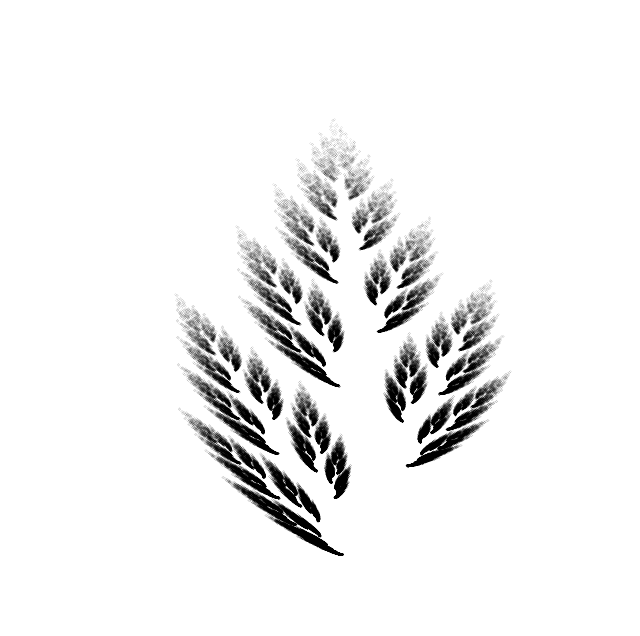

In [93]:
# Ячейка № 6

# визуализация изображения
# фрактала Лист 11-го порядка,
# полученного c помощью ДСИФ,
# с использованием 100 базовых точек
Maple_DSIF(11, 100)